In [98]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [3]:
# 1. Read Csv
titanic = pd.read_csv("Data/Titanic-Dataset.csv")

In [4]:
# 2. EDA
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic.shape

(891, 12)

In [6]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [8]:
titanic.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [9]:
titanic.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
titanic.duplicated().sum()

np.int64(0)

In [12]:
titanic.isna().sum(axis=0)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# 3. Drop Column - Feature Selection
titanic = titanic.drop(["PassengerId"], axis=1)

In [17]:
# 4. Feature Engineering 
titanic["Title"] = titanic["Name"].str.extract( r" ([A-Za-z]+)\.", expand=False)

In [18]:
titanic["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [19]:
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1

In [20]:
titanic["Has_Cabin"] = titanic["Cabin"].notna().astype(int)

In [21]:
# 5. Feature Selection
titanic = titanic.drop(["Name", "Cabin"], axis=1)

In [22]:
# 6. Final Dataset Inspection
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Ticket      891 non-null    object 
 7   Fare        891 non-null    float64
 8   Embarked    889 non-null    object 
 9   Title       891 non-null    object 
 10  FamilySize  891 non-null    int64  
 11  Has_Cabin   891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [25]:
# 7. Feature engineering
titanic["TicketGroupSize"] = titanic.groupby("Ticket")["Ticket"].transform("count")

In [26]:
# 8. Checking Ticket Groups
titanic.groupby("Ticket")["Ticket"].count()

Ticket
110152         3
110413         3
110465         2
110564         1
110813         1
              ..
W./C. 6608     4
W./C. 6609     1
W.E.P. 5734    1
W/C 14208      1
WE/P 5735      2
Name: Ticket, Length: 681, dtype: int64

In [27]:
titanic[["Ticket", "TicketGroupSize"]].head(10)

,Ticket,TicketGroupSize
0,A/5 21171,1
1,PC 17599,1
2,STON/O2. 3101282,1
3,113803,2
4,373450,1
5,330877,1
6,17463,1
7,349909,4
8,347742,3
9,237736,2


In [28]:
# 9. Remove original Ticket column after extracting TicketGroupSize
titanic = titanic.drop(["Ticket"], axis=1)

In [29]:
# 10. Final Dataset Inspection

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    object 
 3   Age              714 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Embarked         889 non-null    object 
 8   Title            891 non-null    object 
 9   FamilySize       891 non-null    int64  
 10  Has_Cabin        891 non-null    int64  
 11  TicketGroupSize  891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


In [30]:
# 11. Define X and y
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

In [33]:
X_train, X_test,y_train, y_test = train_test_split(


X, y, test_size=0.2, random_state=42,
    stratify=y

)

In [34]:
# 12. Check Their Shapes
X_train.shape, X_test.shape

((712, 11), (179, 11))

In [35]:
y_train.shape, y_test.shape

((712,), (179,))

In [36]:
# 13. Check training data

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,Has_Cabin,TicketGroupSize
692,3,male,NaN,0,0,56.4958,S,Mr,1,0,7
481,2,male,NaN,0,0,0.0000,S,Mr,1,0,1
527,1,male,NaN,0,0,221.7792,S,Mr,1,1,1
855,3,female,18.0,0,1,9.3500,S,Mrs,2,0,1
801,2,female,31.0,1,1,26.2500,S,Mrs,3,0,3


In [39]:
# 14. Pipelines
numerical_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "Has_Cabin",
    "TicketGroupSize"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [41]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())
])

In [43]:
categorical_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [44]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [50]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [51]:
# 15. Fit
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
# 16. Predict
y_pred = model_pipeline.predict(X_test)

In [55]:
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [57]:
accuracy = accuracy_score(y_test, y_pred)

In [58]:
accuracy

0.8268156424581006

In [59]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.84      0.88      0.86       110\n           1       0.80      0.74      0.77        69\n\n    accuracy                           0.83       179\n   macro avg       0.82      0.81      0.81       179\nweighted avg       0.83      0.83      0.83       179\n'

In [62]:
# 17. Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [63]:
# 18. Fit
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
# 19. Predict
y_pred_rf = rf_pipeline.predict(X_test)

In [65]:
y_pred_rf

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [67]:
accuracy = accuracy_score(y_test, y_pred_rf)

In [68]:
accuracy

0.770949720670391

In [69]:
classification_report(y_test, y_pred_rf)

'              precision    recall  f1-score   support\n\n           0       0.80      0.84      0.82       110\n           1       0.72      0.67      0.69        69\n\n    accuracy                           0.77       179\n   macro avg       0.76      0.75      0.75       179\nweighted avg       0.77      0.77      0.77       179\n'

In [78]:
# 20. Hyparameter tuning - Random Forest
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}
    

In [79]:
# 21. GridSearchCV
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
    

In [80]:
# 22. Fit
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [81]:
# 23. Best Parameter Combination
grid_search.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 5,
 'model__n_estimators': 300}

In [82]:
# 24. Best Score
grid_search.best_score_

np.float64(0.8301388752092977)

In [84]:
# 25. Best Model Predictions
best_rf = grid_search.best_estimator_

In [86]:
y_pred_best = best_rf.predict(X_test)

In [87]:
# 26. Final Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_best))

Accuracy: 0.7821229050279329


In [88]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [89]:
# 27. # Extract the Trained Random Forest Model From The Pipeline

rf_model = best_rf.named_steps["model"]


In [90]:
# 28. Calculate Feature Importance
importances = rf_model.feature_importances_

In [91]:
# 29. Get Feature Names After Preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

In [95]:
# 30. Create A Dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})


In [96]:
# 31. Sort Features By Importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending = False
)

In [97]:
# 32. Display The Top 10 Most Important Features
feature_importance.head(10)


,Feature,Importance
3,num__Fare,0.133533
24,cat__Title_Mr,0.127961
10,cat__Sex_female,0.117164
11,cat__Sex_male,0.113107
0,num__Age,0.105421
6,num__TicketGroupSize,0.059178
9,cat__Pclass_3,0.054378
4,num__FamilySize,0.044015
5,num__Has_Cabin,0.042885
22,cat__Title_Miss,0.031246


In [99]:
# 33. Visualize Feature Importance
top_features = feature_importance.head(10)

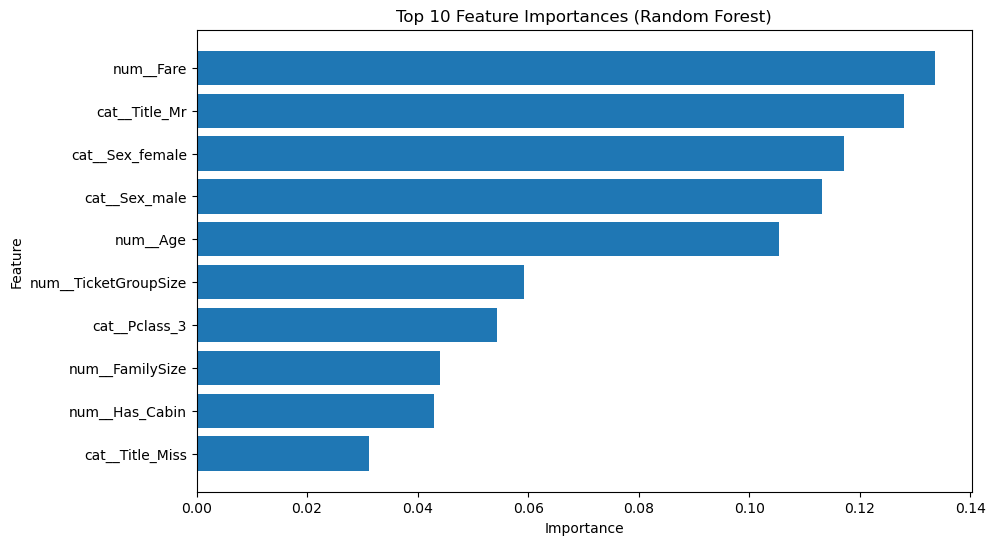

In [101]:
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()